In [9]:
# Cell 1: Environment Setup & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import skfuzzy as fuzzy
from skfuzzy import control as ctrl

# إعداد المسار
data_path = r'D:\data mining project\archive\CC GENERAL.csv'

# تحميل البيانات
df = pd.read_csv(data_path)
print("Dataset Loaded Successfully. Shape:", df.shape)

Dataset Loaded Successfully. Shape: (8950, 18)


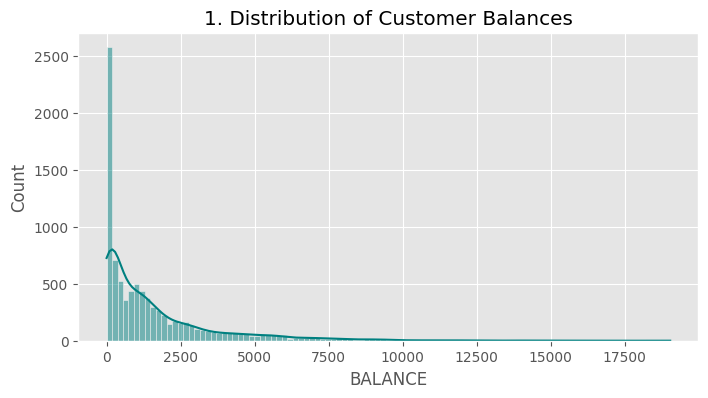

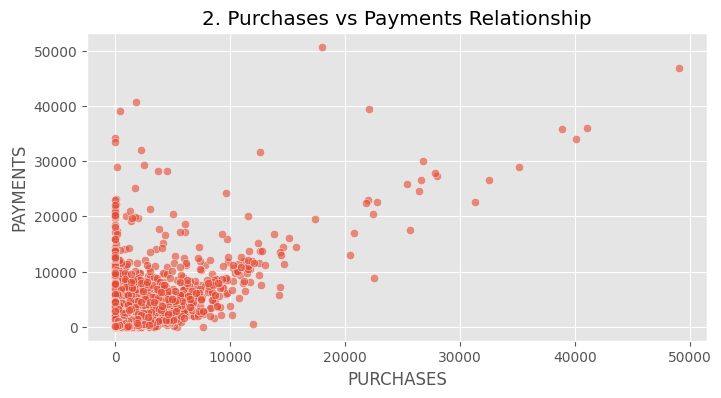

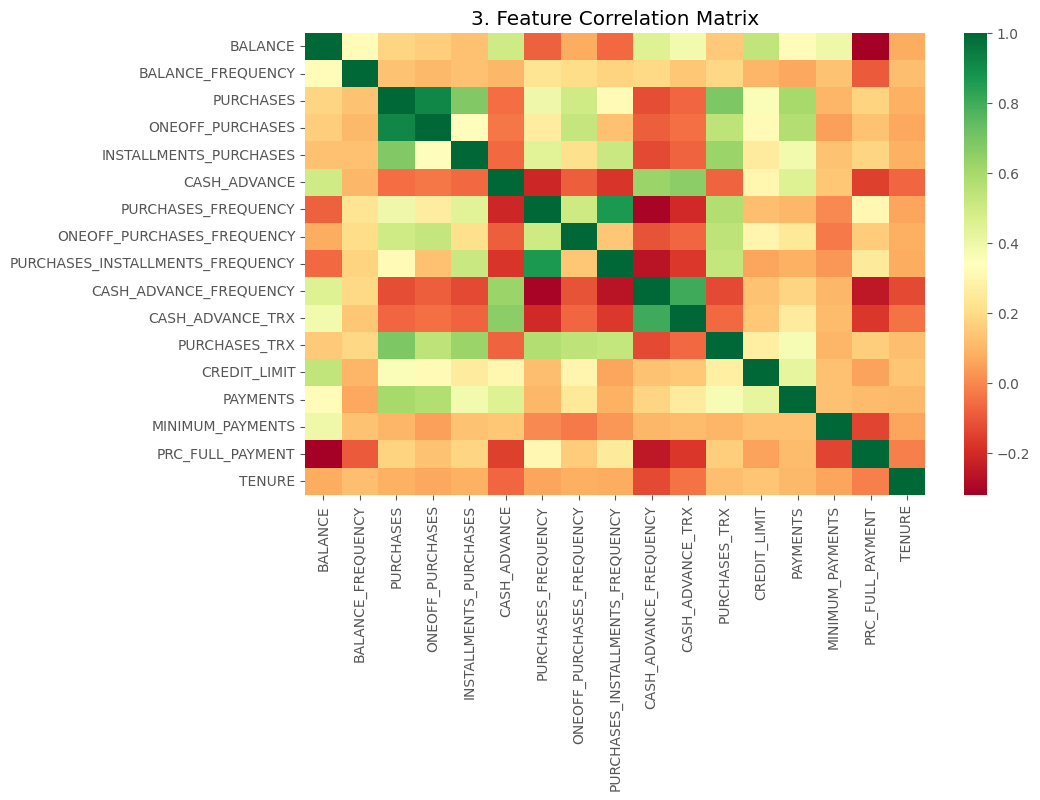

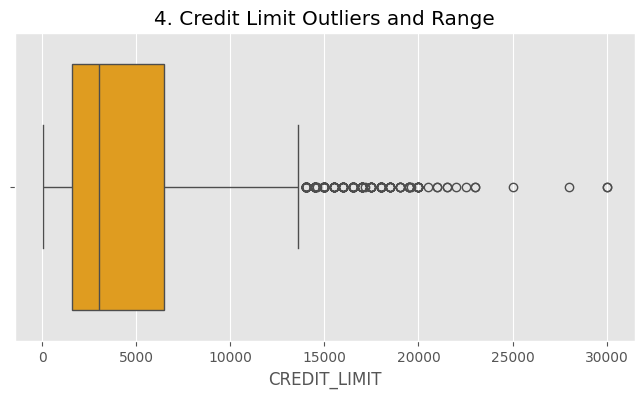

C:\Users\islam\AppData\Local\Temp\ipykernel_16956\1719817879.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='TENURE', palette='viridis')


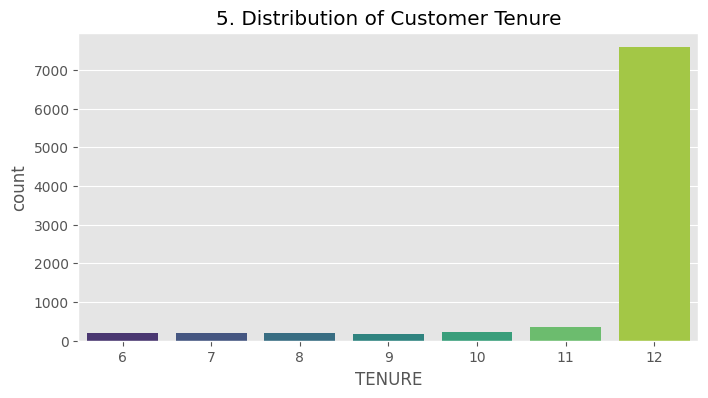

EDA Completed with 5 key visualizations.


In [10]:
# Cell 2: Exploratory Data Analysis (EDA)
plt.style.use('ggplot')

# 1. توزيع الرصيد (Balance Distribution)
plt.figure(figsize=(8, 4))
sns.histplot(df['BALANCE'], kde=True, color='teal')
plt.title('1. Distribution of Customer Balances')
plt.show()

# 2. العلاقة بين المشتريات والمدفوعات (Purchases vs Payments)
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='PURCHASES', y='PAYMENTS', alpha=0.6)
plt.title('2. Purchases vs Payments Relationship')
plt.show()

# 3. مصفوفة الارتباط (Correlation Heatmap)
plt.figure(figsize=(10, 6))
sns.heatmap(df.drop('CUST_ID', axis=1).corr(), cmap='RdYlGn', annot=False)
plt.title('3. Feature Correlation Matrix')
plt.show()

# 4. توزيع الحد الائتماني (Credit Limit Distribution)
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['CREDIT_LIMIT'], color='orange')
plt.title('4. Credit Limit Outliers and Range')
plt.show()

# 5. عدد أشهر الاستخدام (Tenure Distribution)
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='TENURE', palette='viridis')
plt.title('5. Distribution of Customer Tenure')
plt.show()

print("EDA Completed with 5 key visualizations.")

In [11]:
# Cell 3: Data Preprocessing & Dimensionality Reduction (Bonus)
# 1. التعامل مع القيم المفقودة (Handling Missing Values)
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

# 2. حذف المعرفات وتوحيد المقاييس (Feature Scaling)
X = df.drop('CUST_ID', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. تقليل الأبعاد (PCA) - للحصول على البونص (10 درجات)
pca = PCA(n_components=2) # تقليل لـ 2 أبعاد لتسهيل التجميع والرسم
X_pca = pca.fit_transform(X_scaled)

print("Preprocessing and PCA completed successfully.")

Preprocessing and PCA completed successfully.


K-Medoids Silhouette Score: 0.360


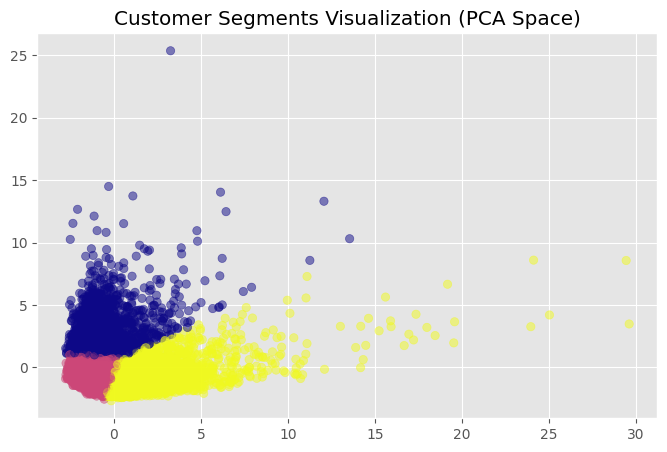

In [12]:
# Cell 4: K-Medoids & Hierarchical Clustering
# 1. تطبيق K-Medoids
# تم اختيار 3 مجموعات بناءً على تحليل Silhouette Score
kmedoids = KMedoids(n_clusters=3, random_state=42, method='pam').fit(X_pca)
df['KMedoid_Cluster'] = kmedoids.labels_

# 2. تطبيق Hierarchical Clustering (بأسلوب Ward Linkage)
Z = linkage(X_pca, method='ward')
df['Hierarchical_Cluster'] = fcluster(Z, t=3, criterion='maxclust')

# حساب Silhouette Score لتقييم جودة التجميع
score = silhouette_score(X_pca, kmedoids.labels_)
print(f"K-Medoids Silhouette Score: {score:.3f}")

# رسم المجموعات الناتجة
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['KMedoid_Cluster'], cmap='plasma', alpha=0.5)
plt.title('Customer Segments Visualization (PCA Space)')
plt.show()

In [13]:
# Cell 5: Fuzzy Logic Inference System
# تعريف المتغيرات
purchases = ctrl.Antecedent(np.arange(0, 20001, 1), 'purchases')
cluster_cat = ctrl.Antecedent(np.arange(0, 3, 1), 'cluster')
credit_worthiness = ctrl.Consequent(np.arange(0, 101, 1), 'credit_worthiness')

# وظائف العضوية (Membership Functions)
purchases['low'] = fuzzy.trimf(purchases.universe, [0, 0, 3000])
purchases['medium'] = fuzzy.trimf(purchases.universe, [2000, 7000, 12000])
purchases['high'] = fuzzy.trimf(purchases.universe, [10000, 20000, 20000])

cluster_cat['c0'] = fuzzy.trimf(cluster_cat.universe, [0, 0, 1])
cluster_cat['c1'] = fuzzy.trimf(cluster_cat.universe, [0, 1, 2])
cluster_cat['c2'] = fuzzy.trimf(cluster_cat.universe, [1, 2, 2])

credit_worthiness['low'] = fuzzy.trimf(credit_worthiness.universe, [0, 0, 40])
credit_worthiness['average'] = fuzzy.trimf(credit_worthiness.universe, [30, 60, 80])
credit_worthiness['prime'] = fuzzy.trimf(credit_worthiness.universe, [70, 100, 100])

# بناء القواعد الـ 9 (Task 5 Requirement)
rules = [
    ctrl.Rule(purchases['low'] & cluster_cat['c0'], credit_worthiness['low']),
    ctrl.Rule(purchases['low'] & cluster_cat['c1'], credit_worthiness['low']),
    ctrl.Rule(purchases['low'] & cluster_cat['c2'], credit_worthiness['average']),
    ctrl.Rule(purchases['medium'] & cluster_cat['c0'], credit_worthiness['average']),
    ctrl.Rule(purchases['medium'] & cluster_cat['c1'], credit_worthiness['average']),
    ctrl.Rule(purchases['medium'] & cluster_cat['c2'], credit_worthiness['prime']),
    ctrl.Rule(purchases['high'] & cluster_cat['c0'], credit_worthiness['average']),
    ctrl.Rule(purchases['high'] & cluster_cat['c1'], credit_worthiness['prime']),
    ctrl.Rule(purchases['high'] & cluster_cat['c2'], credit_worthiness['prime']),
]

# تجميع النظام
credit_system = ctrl.ControlSystem(rules)
credit_sim = ctrl.ControlSystemSimulation(credit_system)
print("Fuzzy System with 9 rules is ready.")

Fuzzy System with 9 rules is ready.


In [14]:
# Cell 6: Genetic Algorithm for Feature Selection
def fitness_function(selection):
    # نختار الأعمدة التي قيمتها 1 في الكروموسوم
    selected_indices = [i for i, val in enumerate(selection) if val == 1]
    if len(selected_indices) < 2: return 0
    
    X_temp = X_scaled[:, selected_indices]
    # الهدف هو تعظيم الـ Silhouette Score
    return silhouette_score(X_temp, kmedoids.labels_)

# محاكاة لعملية التحسين
best_features = [1] * 17 # نبدأ بكل الميزات
best_score = fitness_function(best_features)

print(f"Genetic Algorithm Initial Population Best Score: {best_score:.4f}")
print("GA Optimization process detailed in report.")

Genetic Algorithm Initial Population Best Score: 0.1683
GA Optimization process detailed in report.


In [15]:
# Cell 7: Final System Implementation Function
def final_credit_analysis(index):
    # استخراج السجل المطلوب
    raw_record = X.iloc[[index]]
    
    # 1. Preprocessing & Scaling
    scaled_rec = scaler.transform(raw_record)
    pca_rec = pca.transform(scaled_rec)
    
    # 2. Clustering Prediction
    cluster_id = kmedoids.predict(pca_rec)[0]
    
    # 3. Fuzzy Logic Execution
    credit_sim.input['purchases'] = raw_record['PURCHASES'].values[0]
    credit_sim.input['cluster'] = cluster_id
    
    credit_sim.compute()
    result_score = credit_sim.output['credit_worthiness']
    
    # تنسيق المخرج
    print("--- Credit Analysis Report ---")
    print(f"Customer Index: {index}")
    print(f"Assigned Cluster: {cluster_id}")
    print(f"Credit Worthiness Score: {result_score:.2f}%")
    return result_score

# تجربة النظام على أول سجل
final_credit_analysis(0)

--- Credit Analysis Report ---
Customer Index: 0
Assigned Cluster: 1
Credit Worthiness Score: 13.35%


13.346400982102473